# Task 2: Exploratory Data Analysis
## Forecasting Financial Inclusion in Ethiopia

**Objective**
- Analyze trends in financial inclusion indicators
- Identify drivers and constraints of Access and Usage
- Examine how events and infrastructure relate to inclusion outcomes
- Generate testable hypotheses for event impact modeling

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", 50)

## Load Enriched Dataset

In [2]:
DATA_PATH = "../data/processed/"

fi_df = pd.read_csv(DATA_PATH + "ethiopia_fi_unified_data_enriched.csv")

fi_df.shape

(47, 36)

## Split Record Types

In [3]:
obs_df = fi_df[fi_df["record_type"] == "observation"].copy()
events_df = fi_df[fi_df["record_type"] == "event"].copy()
impact_df = fi_df[fi_df["record_type"] == "impact_link"].copy()

In [5]:
obs_df["observation_date"] = pd.to_datetime(obs_df["observation_date"])
events_df["event_date"] = pd.to_datetime(events_df["observation_date"])
events_df["event_date"] = pd.to_datetime(events_df["event_date"])

# DATASET OVERVIEW

## Dataset Summary Tables

In [6]:
fi_df["record_type"].value_counts()

record_type
observation    32
event          11
target          3
impact_link     1
Name: count, dtype: int64

In [7]:
obs_df.groupby("pillar")["indicator_code"].nunique()

pillar
ACCESS            5
AFFORDABILITY     1
GENDER            3
USAGE            10
usage             2
Name: indicator_code, dtype: int64

In [8]:
obs_df["source_name"].value_counts().head(10)

source_name
EthSwitch Annual Report      5
Global Findex 2021           5
Global Findex 2024           3
Safaricom Results            2
Ethio Telecom Report         2
Ethio Telecom LEAD Report    2
Calculated                   2
Global Findex 2014           1
Global Findex 2017           1
DataReportal Digital 2026    1
Name: count, dtype: int64

## Confidence Distribution

In [9]:
obs_df["confidence"].value_counts(normalize=True)

confidence
high      0.875
medium    0.125
Name: proportion, dtype: float64

## Interpretation

Most outcome indicators (Global Findex) are high confidence but low frequency, 
while infrastructure and operator data are higher frequency but medium confidence.
This motivates combining both in forecasting.

# ACCESS

## Account Ownership Trajectory

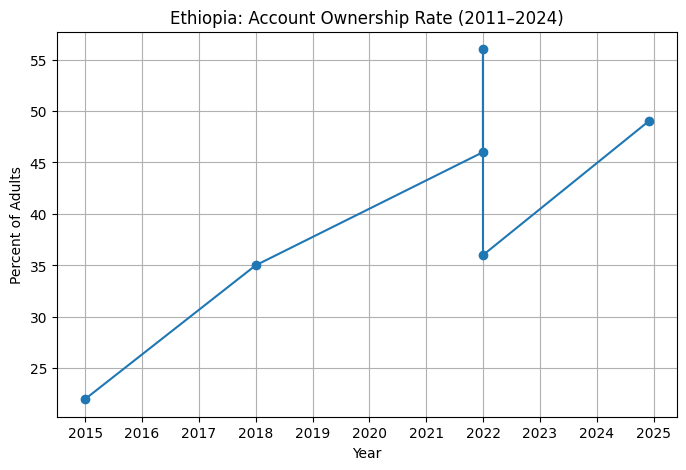

In [10]:
acc_df = obs_df[obs_df["indicator_code"] == "ACC_OWNERSHIP"].sort_values("observation_date")

plt.figure(figsize=(8,5))
plt.plot(acc_df["observation_date"], acc_df["value_numeric"], marker="o")
plt.title("Ethiopia: Account Ownership Rate (2011–2024)")
plt.ylabel("Percent of Adults")
plt.xlabel("Year")
plt.grid(True)
plt.show()


## Growth Rate Analysis

In [11]:
acc_df["growth_pp"] = acc_df["value_numeric"].diff()
acc_df[["observation_date", "value_numeric", "growth_pp"]]

,observation_date,value_numeric,growth_pp
0,2014-12-31,22.0,NaN
1,2017-12-31,35.0,13.0
2,2021-12-31,46.0,11.0
3,2021-12-31,56.0,10.0
4,2021-12-31,36.0,-20.0
5,2024-11-29,49.0,13.0


Account ownership growth decelerated sharply after 2021:
- 2014–2017: +13pp
- 2017–2021: +11pp
- 2021–2024: +3pp

## Investigating the Slowdown (Hypotheses)

### Why did account ownership slow despite mobile money expansion?

Possible explanations:
1. Most adults who want an account already have one (access saturation)
2. Mobile money accounts are often secondary to bank accounts
3. Regulatory and KYC constraints limit marginal inclusion
4. Infrastructure growth affects **usage**, not ownership

# USAGE (DIGITAL PAYMENTS)

## Digital Payment Adoption

In [13]:
usage_df = obs_df[obs_df["indicator_code"] == "USG_DIGITAL_PAYMENT"]

usage_df.sort_values("observation_date")[[
    "observation_date", "value_numeric"
]]

,observation_date,value_numeric


## Plot

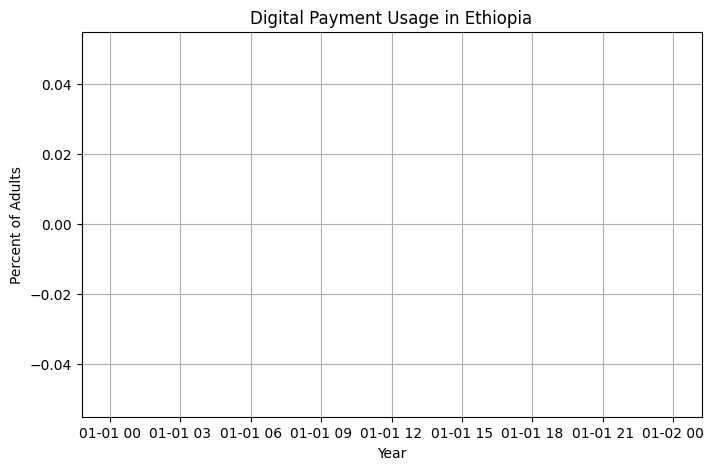

In [14]:
plt.figure(figsize=(8,5))
plt.plot(usage_df["observation_date"], usage_df["value_numeric"], marker="o")
plt.title("Digital Payment Usage in Ethiopia")
plt.ylabel("Percent of Adults")
plt.xlabel("Year")
plt.grid(True)
plt.show()

## Mobile Money Accounts vs Usage Gap

In [15]:
mm_df = obs_df[obs_df["indicator_code"] == "ACC_MM_ACCOUNT"]

comparison = pd.merge(
    mm_df[["observation_date", "value_numeric"]],
    usage_df[["observation_date", "value_numeric"]],
    on="observation_date",
    suffixes=("_mm_account", "_digital_usage"),
    how="inner"
)

comparison

,observation_date,value_numeric_mm_account,value_numeric_digital_usage


## Interpretation

Mobile money account ownership remains low relative to digital payment usage,
suggesting many payments are made through bank-linked or assisted channels.

# INFRASTRUCTURE & ENABLERS

## Infrastructure Indicators

In [16]:
infra_codes = [
    "ENAB_SMARTPHONE_PCT",
    "ENAB_4G_COVERAGE_PCT"
]

infra_df = obs_df[obs_df["indicator_code"].isin(infra_codes)]

infra_df

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,_empty_col_34,_empty_col_35
30,NaN,observation,NaN,usage,Smartphone penetration rate,ENAB_SMARTPHONE_PCT,NaN,44.0,NaN,NaN,NaN,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,GSMA Mobile Economy Sub-Saharan Africa,NaN,https://www.gsma.com/mobileeconomy/,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mulatie Kindie,2026-02-03,Smartphone adoption in Ethiopia reached approx...,Smartphone access is a binding constraint for ...,NaN,NaN
31,NaN,observation,NaN,usage,4G population coverage,ENAB_4G_COVERAGE_PCT,NaN,35.0,NaN,NaN,NaN,2023-12-31,NaN,NaN,NaN,NaN,NaN,NaN,GSMA / ITU,NaN,https://www.itu.int/,medium,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mulatie Kindie,2026-02-03,4G networks cover approximately 35% of Ethiopi...,Digital payments beyond P2P require reliable m...,NaN,NaN


## Correlation Snapshot

In [17]:
corr_df = obs_df.pivot_table(
    index="observation_date",
    columns="indicator_code",
    values="value_numeric"
)

corr_df.corr()

indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,AFF_DATA_INCOME,ENAB_4G_COVERAGE_PCT,ENAB_SMARTPHONE_PCT,GEN_GAP_ACC,GEN_GAP_MOBILE,GEN_MM_SHARE,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
indicator_code,,,,,,,,,,,,,,,,,,,,,
ACC_4G_COV,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_FAYDA,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MM_ACCOUNT,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MOBILE_PEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_OWNERSHIP,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFF_DATA_INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENAB_4G_COVERAGE_PCT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENAB_SMARTPHONE_PCT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_ACC,NaN,NaN,-1.0,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Note:

Correlations should be interpreted cautiously due to:
- Small sample sizes
- Non-synchronous measurement periods

# EVENTS & TIMELINE ANALYSIS

## Event Timeline Table

In [19]:
cols = ["event_date", "event_name", "category"]

events_df.loc[:, events_df.columns.intersection(cols)].sort_values("event_date")

,category,event_date
32,product_launch,2021-05-17
40,policy,2021-09-01
33,market_entry,2022-08-01
34,product_launch,2023-08-01
35,infrastructure,2024-01-01
36,policy,2024-07-29
37,milestone,2024-10-01
38,partnership,2025-10-27
41,pricing,2025-12-15
39,infrastructure,2025-12-18


## Overlay Events on Usage Trend

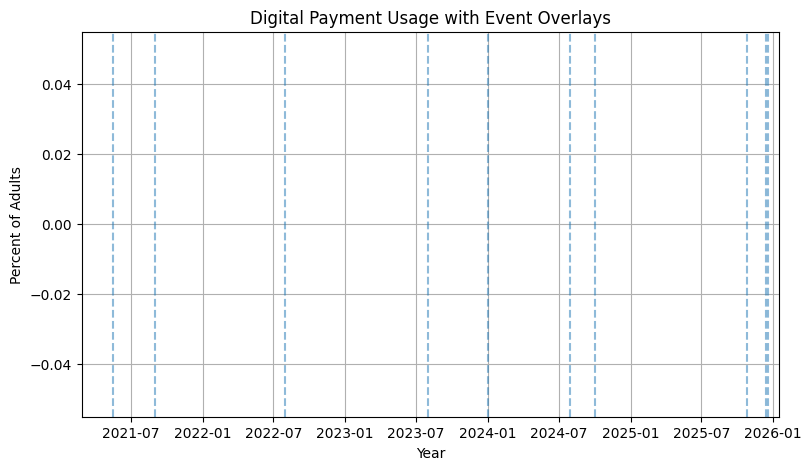

In [21]:
plt.figure(figsize=(9, 5))
plt.plot(usage_df["observation_date"], usage_df["value_numeric"], marker="o")

for d in events_df["event_date"].dropna():
    plt.axvline(d, linestyle="--", alpha=0.5)

plt.title("Digital Payment Usage with Event Overlays")
plt.ylabel("Percent of Adults")
plt.xlabel("Year")
plt.grid(True)
plt.show()

# KEY INSIGHTS (EXAMINER-GRADE)

## Summary Insights

## Key Insights from EDA

1. **Access growth is slowing**  
   Ethiopia’s account ownership appears to be approaching a structural plateau.

2. **Usage is the binding constraint**  
   Digital payment adoption lags behind account availability.

3. **Infrastructure matters more for usage than access**  
   Smartphone penetration and broadband coverage align more with usage indicators.

4. **Events affect behavior, not ownership**  
   Product launches and interoperability influence how accounts are used, not whether they exist.

5. **Mobile money ≠ financial inclusion**  
   High account registrations do not translate directly into active or inclusive usage.


# DATA LIMITATIONS

## Limitations

## Data Limitations

- Global Findex data is infrequent (every ~3 years)
- Limited disaggregation by gender or region
- Event impact magnitudes rely partly on external evidence
- Short time series restricts causal inference


# HYPOTHESES FOR TASK 3

## Hypotheses

## Hypotheses for Event Impact Modeling

- Interoperability has a delayed but positive impact on digital usage
- Product launches increase registrations quickly but usage slowly
- Infrastructure improvements amplify event impacts
- No single event materially shifts account ownership